
# Advanced KNN Classification — Credit Card Tier Prediction (Synthetic Data) — **Compat Version**

Incluye: Simulación → EDA → Feature Engineering → Cross-Validation → Entrenamiento → Evaluación (accuracy, precision, recall, f1-score, **AUC multiclass**) → Exportación del modelo.

> Esta versión añade **compatibilidad** de `OneHotEncoder` para distintas versiones de scikit-learn (maneja `sparse_output` vs `sparse`).


## 1) Setup e imports

In [1]:

# !pip install numpy pandas scikit-learn matplotlib  # si fuera necesario

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import OneHotEncoder, StandardScaler, label_binarize
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    classification_report, accuracy_score, f1_score,
    roc_auc_score, roc_curve, auc, confusion_matrix
)
import sklearn
from datetime import datetime

plt.rcParams.update({"figure.figsize": (10,6), "axes.grid": True})
np.random.seed(999)

print("scikit-learn version:", sklearn.__version__)


scikit-learn version: 1.6.1


## 2) Simulación del dataset

In [2]:

n = 1200
cities = np.array(["San Salvador", "Santa Ana", "San Miguel", "La Libertad", "Sonsonate", "La Unión"])
job_types = np.array(["Student", "Clerk", "Technician", "Professional", "Manager", "Self-Employed"])

city = np.random.choice(cities, size=n, p=[0.35, 0.18, 0.15, 0.15, 0.1, 0.07])
job  = np.random.choice(job_types, size=n, p=[0.08, 0.25, 0.22, 0.22, 0.15, 0.08])

age = np.random.randint(18, 75, size=n)
tenure_years = np.clip((age - 18) / 5 + np.random.normal(0, 2, size=n), 0, None)
dependents = np.random.choice([0,1,2,3,4], size=n, p=[0.45,0.25,0.18,0.08,0.04])
num_products = np.random.choice([1,2,3,4,5], size=n, p=[0.35,0.35,0.18,0.08,0.04])

job_income_base = {"Student":350, "Clerk":700, "Technician":950, "Professional":1400, "Manager":2000, "Self-Employed":1200}
city_income_factor = {"San Salvador":1.15, "Santa Ana":0.95, "San Miguel":1.0, "La Libertad":1.05, "Sonsonate":0.9, "La Unión":0.85}

base_income = np.array([job_income_base[j] for j in job]) * np.array([city_income_factor[c] for c in city])
income = np.exp(np.log(base_income + 1) + np.random.normal(0, 0.35, size=n))

credit_score = np.clip(550 + 0.015*(income - income.mean()) + 0.9*np.random.normal(0, 40, size=n) + 0.6*(age-40), 300, 850)
is_active = (np.random.rand(n) < (0.45 + 0.0003*(credit_score - 550))).astype(int)
has_mortgage = (np.random.rand(n) < (0.2 + 0.00025*(age - 25) + 0.00015*(income - 900))).astype(int)
balance = np.clip(np.random.normal(income*(0.4 + 0.18*is_active), income*0.12), 0, None)
spending_score = np.clip(40 + 0.02*(income - income.mean()) + 15*is_active + 5*(num_products-1) + np.random.normal(0,10,size=n), 0, 100)

job_effect = np.array([{"Student":-0.5,"Clerk":-0.2,"Technician":0.0,"Professional":0.25,"Manager":0.5,"Self-Employed":0.15}[j] for j in job])
city_effect = np.array([{"San Salvador":0.25,"Santa Ana":0.05,"San Miguel":0.1,"La Libertad":0.15,"Sonsonate":-0.05,"La Unión":-0.1}[c] for c in city])

score = (
    0.45*(credit_score-500)/350 + 0.20*np.log1p(income)/np.log1p(income).mean()
    + 0.10*(tenure_years/(tenure_years.max()+1)) + 0.10*(balance/(income+1))
    + 0.05*(num_products-1)/4.0 + 0.05*is_active - 0.05*dependents
    + job_effect + city_effect + np.random.normal(0, 0.15, size=n)
)
q1, q2 = np.quantile(score, [0.45, 0.8])
tier = np.where(score < q1, "Silver", np.where(score < q2, "Gold", "Platinum"))

df = pd.DataFrame({
    "age": age, "tenure_years": tenure_years.round(1), "dependents": dependents, "num_products": num_products,
    "income": income.round(2), "credit_score": credit_score.round(0), "is_active": is_active, "has_mortgage": has_mortgage,
    "balance": balance.round(2), "spending_score": spending_score.round(1),
    "city": city, "job_type": job, "target_tier": tier
})
df.head()


,age,tenure_years,dependents,num_products,income,credit_score,is_active,has_mortgage,balance,spending_score,city,job_type,target_tier
0,67,8.4,3,3,1050.41,592.0,0,1,609.98,46.7,La Libertad,Clerk,Silver
1,42,5.9,1,2,377.66,495.0,0,0,102.72,22.7,Santa Ana,Clerk,Silver
2,42,6.6,4,3,1266.71,545.0,0,0,600.18,32.4,San Salvador,Clerk,Silver
3,36,4.8,1,2,1429.48,548.0,0,0,525.32,49.3,San Miguel,Professional,Gold
4,69,10.0,1,2,798.11,563.0,0,0,236.42,40.2,San Salvador,Technician,Silver


## 3) EDA

Shape: (1200, 13)
Distribución de clases:
 target_tier
Silver      540
Gold        420
Platinum    240
Name: count, dtype: int64


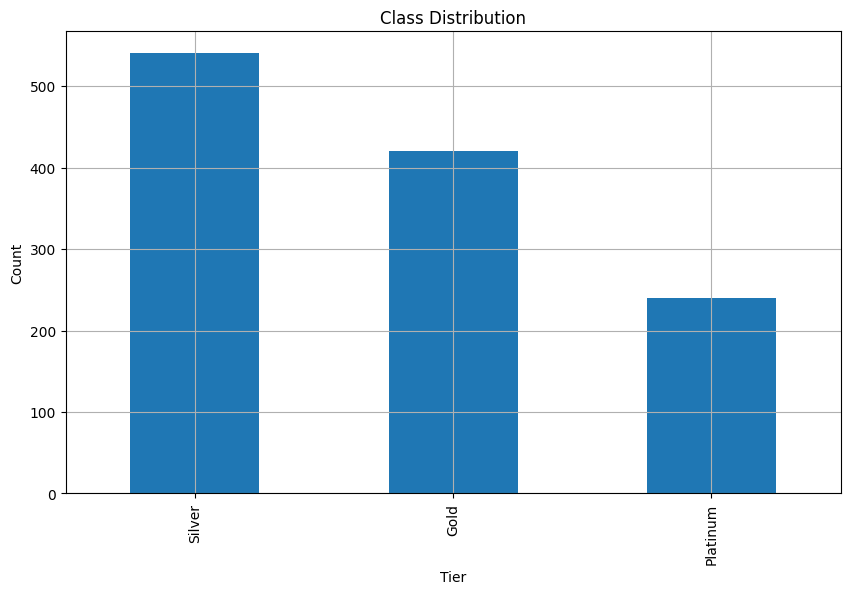

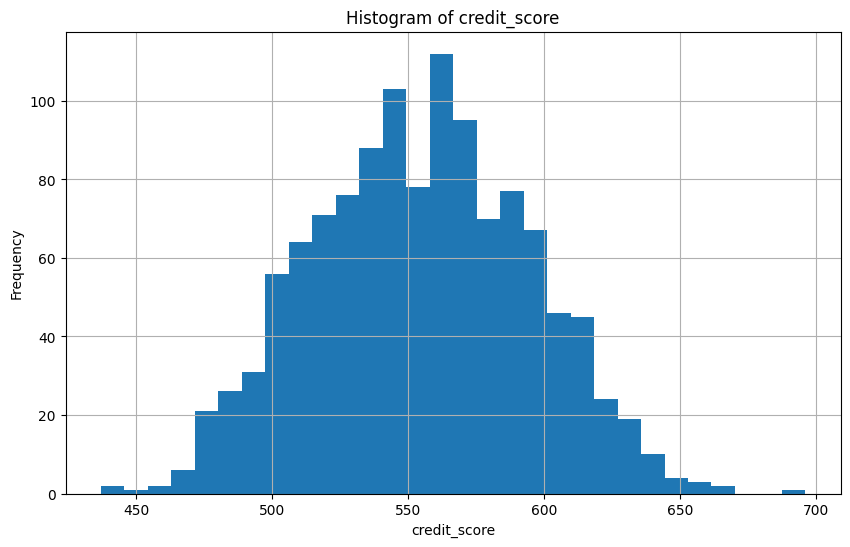

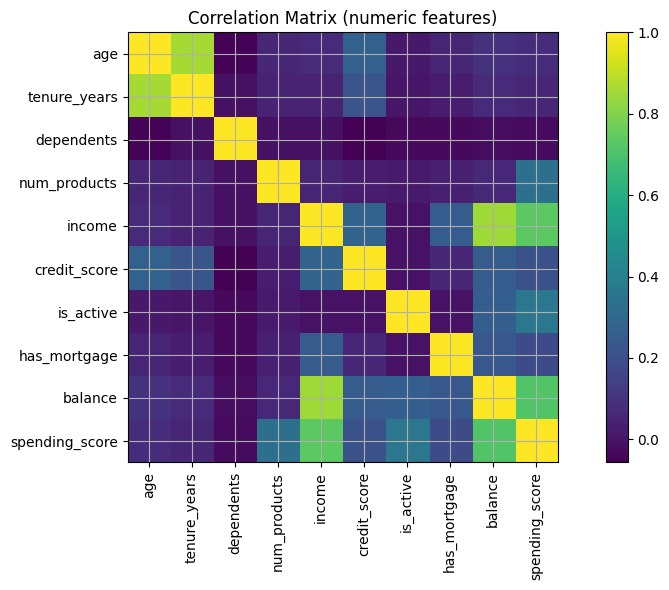

In [3]:

print("Shape:", df.shape)
print("Distribución de clases:\n", df["target_tier"].value_counts())

df["target_tier"].value_counts().plot(kind="bar", title="Class Distribution")
plt.xlabel("Tier"); plt.ylabel("Count"); plt.show()

plt.hist(df["credit_score"], bins=30)
plt.title("Histogram of credit_score"); plt.xlabel("credit_score"); plt.ylabel("Frequency"); plt.show()

numeric_cols = ["age","tenure_years","dependents","num_products","income","credit_score","is_active","has_mortgage","balance","spending_score"]
corr = df[numeric_cols].corr()
plt.imshow(corr, interpolation="nearest")
plt.xticks(range(len(numeric_cols)), numeric_cols, rotation=90)
plt.yticks(range(len(numeric_cols)), numeric_cols)
plt.title("Correlation Matrix (numeric features)"); plt.colorbar(); plt.tight_layout(); plt.show()


## 4) Feature Engineering + **Compat OHE**

In [4]:

df["income_per_dependent"] = df["income"] / (1 + df["dependents"])
df["balance_to_income"]   = df["balance"] / (1 + df["income"])
df["tenure_per_age"]      = df["tenure_years"] / (df["age"] + 1)

features = [
    "age","tenure_years","dependents","num_products","income","credit_score",
    "is_active","has_mortgage","balance","spending_score",
    "income_per_dependent","balance_to_income","tenure_per_age",
    "city","job_type",
]
X = df[features].copy()
y = df["target_tier"].copy()

cat_features = ["city","job_type"]
num_features = [c for c in features if c not in cat_features]

# --- Compatibilidad OneHotEncoder ---
if sklearn.__version__ >= "1.2":
    ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
else:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse=False)

preprocess = ColumnTransformer([
    ("num", StandardScaler(), num_features),
    ("cat", ohe, cat_features),
])

X.shape, y.value_counts()


((1200, 15),
 target_tier
 Silver      540
 Gold        420
 Platinum    240
 Name: count, dtype: int64)

## 5) Cross-Validation (3-fold, submuestra estratificada)

CV f1_weighted (mean±std): 0.6191 ± 0.0394
CV accuracy (mean±std): 0.6201 ± 0.0403


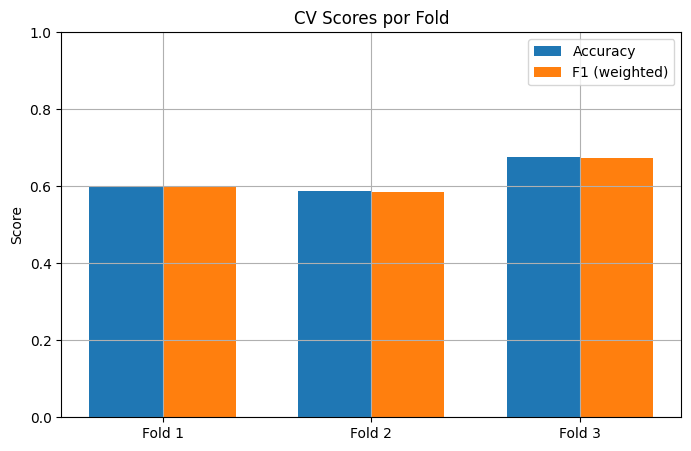

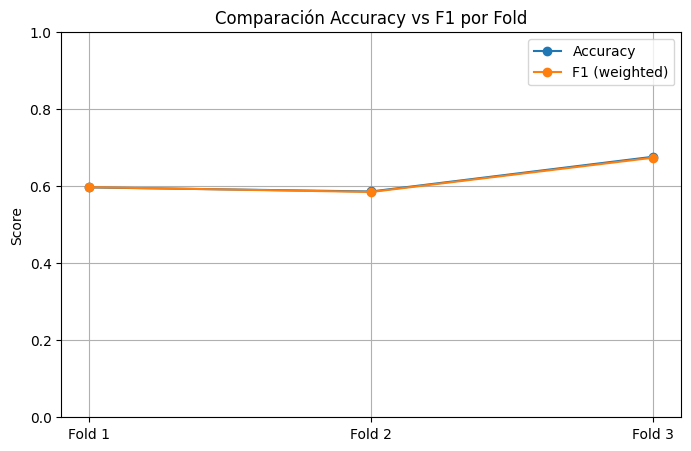

C:\Users\Admin\AppData\Local\Temp\ipykernel_27552\1946370646.py:91: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


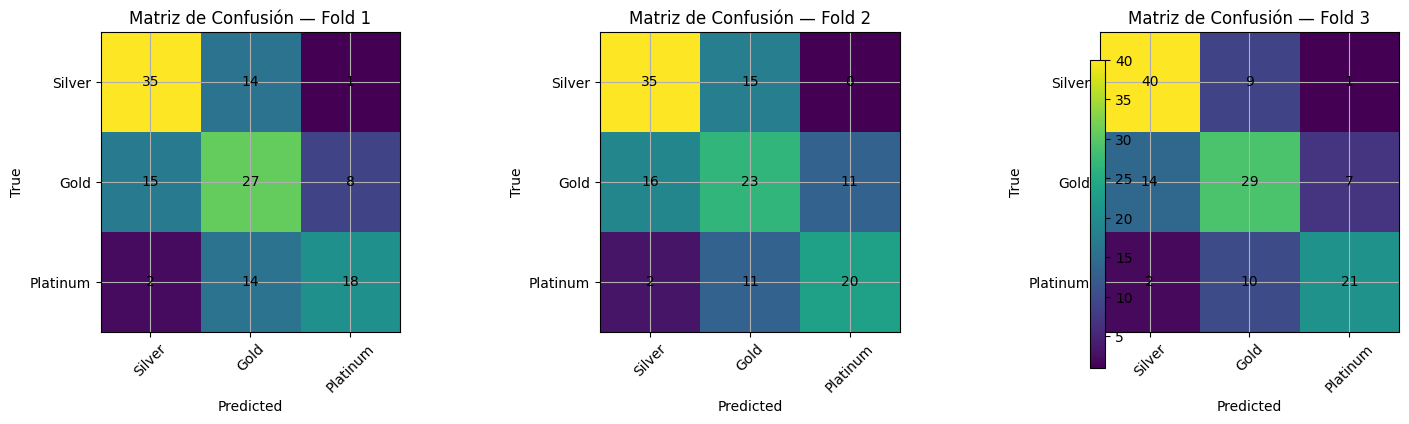

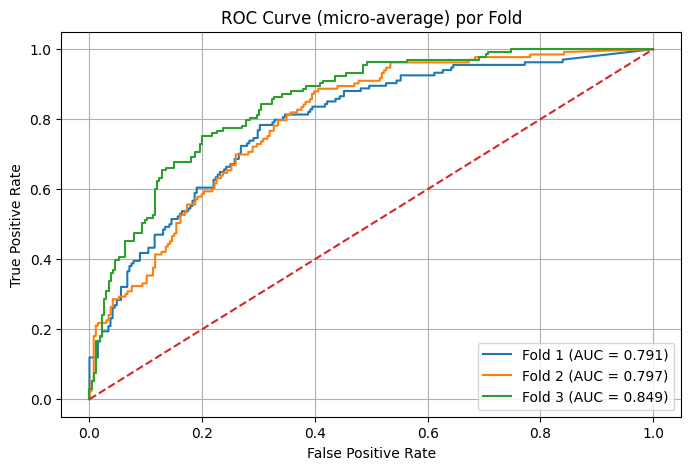

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    f1_score, accuracy_score, confusion_matrix,
    roc_curve, auc
)
from sklearn.preprocessing import label_binarize

# --- Modelo y split ---
knn = KNeighborsClassifier(n_neighbors=15, weights="distance", p=2)
pipe = Pipeline([("preprocess", preprocess), ("model", knn)])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=999
)

sub_idx = np.concatenate([
    np.random.choice(np.where(y_train==cls)[0],
                     size=min(150 if cls!="Platinum" else 100, np.sum(y_train==cls)),
                     replace=False)
    for cls in ["Silver","Gold","Platinum"]
])
X_sub, y_sub = X_train.iloc[sub_idx], y_train.iloc[sub_idx]

# --- Cross-Validation + métricas/artefactos ---
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=999)

fold_acc, fold_f1 = [], []
fold_confms = []
fold_preds, fold_trues = [], []   # <-- corregido: dos listas
class_order = ["Silver","Gold","Platinum"]

for fold_idx, (tr, va) in enumerate(cv.split(X_sub, y_sub), start=1):
    pipe.fit(X_sub.iloc[tr], y_sub.iloc[tr])
    preds = pipe.predict(X_sub.iloc[va])
    acc = accuracy_score(y_sub.iloc[va], preds)
    f1w = f1_score(y_sub.iloc[va], preds, average="weighted")
    cm = confusion_matrix(y_sub.iloc[va], preds, labels=class_order)

    fold_acc.append(acc)
    fold_f1.append(f1w)
    fold_confms.append(cm)
    fold_preds.append(pipe.predict_proba(X_sub.iloc[va]))
    fold_trues.append(y_sub.iloc[va].to_numpy())

print("CV f1_weighted (mean±std):", f"{np.mean(fold_f1):.4f} ± {np.std(fold_f1):.4f}")
print("CV accuracy (mean±std):",   f"{np.mean(fold_acc):.4f} ± {np.std(fold_acc):.4f}")

# ---------- GRÁFICOS ----------
# 1) Barras: Accuracy y F1 por fold
fold_ids = np.arange(1, len(fold_acc)+1)

plt.figure(figsize=(8,5))
width = 0.35
plt.bar(fold_ids - width/2, fold_acc, width, label="Accuracy")
plt.bar(fold_ids + width/2, fold_f1,  width, label="F1 (weighted)")
plt.xticks(fold_ids, [f"Fold {i}" for i in fold_ids])
plt.ylabel("Score")
plt.title("CV Scores por Fold")
plt.legend()
plt.ylim(0, 1.0)
plt.show()

# 2) Líneas: Accuracy vs F1 por fold
plt.figure(figsize=(8,5))
plt.plot(fold_ids, fold_acc, marker="o", label="Accuracy")
plt.plot(fold_ids, fold_f1,  marker="o", label="F1 (weighted)")
plt.xticks(fold_ids, [f"Fold {i}" for i in fold_ids])
plt.ylabel("Score")
plt.title("Comparación Accuracy vs F1 por Fold")
plt.ylim(0, 1.0)
plt.legend()
plt.show()

# 3) Matrices de confusión por fold
fig, axes = plt.subplots(1, len(fold_confms), figsize=(15,4))
for i, cm in enumerate(fold_confms):
    ax = axes[i]
    im = ax.imshow(cm, interpolation="nearest")
    ax.set_title(f"Matriz de Confusión — Fold {i+1}")
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")
    ax.set_xticks(range(len(class_order))); ax.set_yticks(range(len(class_order)))
    ax.set_xticklabels(class_order, rotation=45); ax.set_yticklabels(class_order)
    for r in range(cm.shape[0]):
        for c in range(cm.shape[1]):
            ax.text(c, r, cm[r, c], ha="center", va="center")
fig.colorbar(im, ax=axes.ravel().tolist())
plt.tight_layout()
plt.show()

# 4) (Opcional) ROC micro-average por fold
plot_roc = True
if plot_roc:
    plt.figure(figsize=(8,5))
    for i, (proba, y_true) in enumerate(zip(fold_preds, fold_trues), start=1):
        # Alinear columnas de predict_proba al orden deseado
        model_order = list(pipe.named_steps["model"].classes_)
        col_idx = [model_order.index(c) for c in class_order]
        proba_ord = proba[:, col_idx]
        y_bin = label_binarize(y_true, classes=class_order)
        fpr, tpr, _ = roc_curve(y_bin.ravel(), proba_ord.ravel())
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f"Fold {i} (AUC = {roc_auc:.3f})")

    plt.plot([0,1],[0,1], linestyle="--")
    plt.title("ROC Curve (micro-average) por Fold")
    plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
    plt.legend(loc="lower right")
    plt.show()


## 6) Entrenamiento final

In [6]:

pipe.fit(X_train, y_train)


Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['age', 'tenure_years',
                                                   'dependents', 'num_products',
                                                   'income', 'credit_score',
                                                   'is_active', 'has_mortgage',
                                                   'balance', 'spending_score',
                                                   'income_per_dependent',
                                                   'balance_to_income',
                                                   'tenure_per_age']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['city', 'job_type'])])),
                ('model',
                 KNeighborsClassifier(n_neighbors=15, weights='distance'))])

Cuando hablamos de **AUC (Area Under the Curve)** normalmente nos referimos al área bajo la **curva ROC** en un problema binario: qué tan bien un modelo separa entre **positivos** y **negativos**.

En problemas **multiclase** (como el tuyo: *Silver, Gold, Platinum*), no existe una única curva ROC, porque hay más de dos clases. Para resolverlo se usan estrategias de **reducción a binario**:

---

### One-vs-Rest (OVR)

También llamado *One-vs-All*.

- Se toma una clase como “positiva” y se agrupan todas las demás como “negativas”.  
- Se entrena/estima una curva ROC para cada clase con esa visión binaria.  

**Por ejemplo:**
- ROC para *Silver vs (Gold+Platinum)*  
- ROC para *Gold vs (Silver+Platinum)*  
- ROC para *Platinum vs (Silver+Gold)*  

Cada curva da un **AUC distinto**.

---

### Promedios de AUC

- **Macro average:** Promedia los AUC de cada clase (todas pesan igual).  
- **Weighted average:** Promedia los AUC ponderando por el número de ejemplos de cada clase.  


## 7) Evaluación + AUC multiclass (OVR)

Accuracy: 0.7

Classification Report:
               precision    recall  f1-score   support

        Gold     0.6104    0.5595    0.5839        84
    Platinum     0.7436    0.6042    0.6667        48
      Silver     0.7419    0.8519    0.7931       108

    accuracy                         0.7000       240
   macro avg     0.6986    0.6718    0.6812       240
weighted avg     0.6962    0.7000    0.6946       240

ROC AUC (macro, OVR): 0.8568
ROC AUC (weighted, OVR): 0.8514


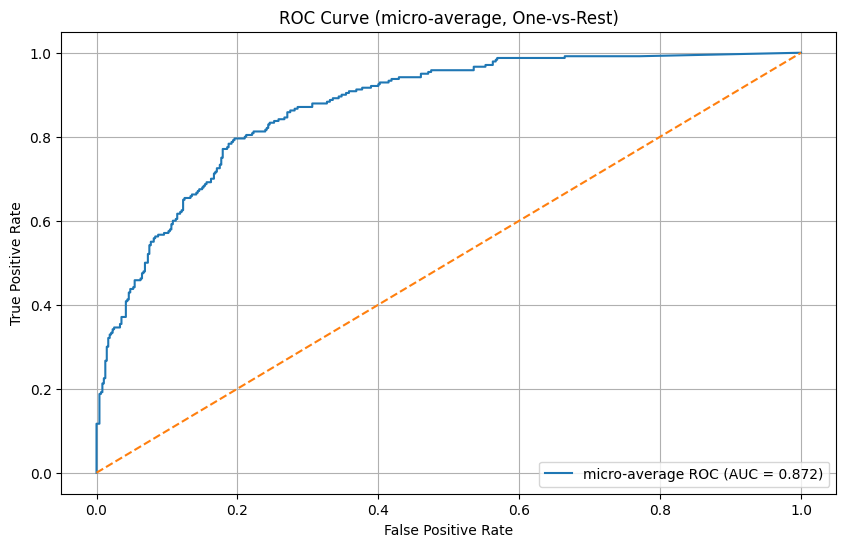

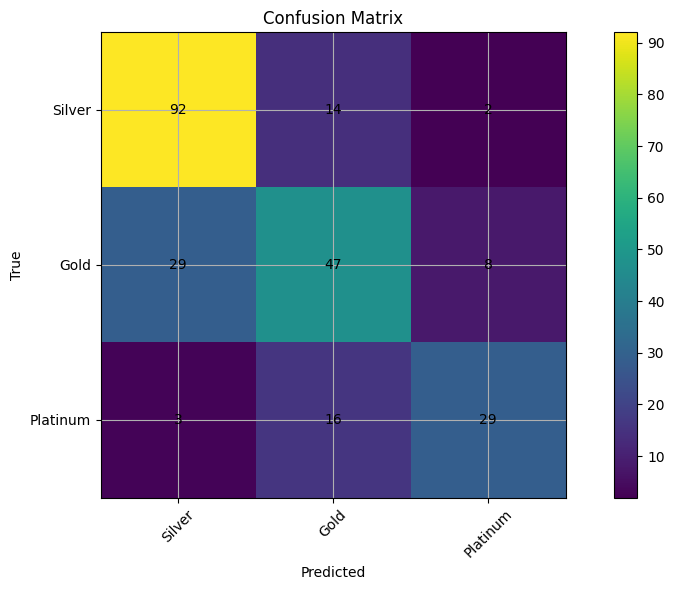

In [7]:

y_pred = pipe.predict(X_test)
print("Accuracy:", round(accuracy_score(y_test, y_pred), 4))
print("\nClassification Report:\n", classification_report(y_test, y_pred, digits=4))

# Alinear orden de clases para AUC correcto
desired_order = ["Silver","Gold","Platinum"]
model_order = list(pipe.named_steps["model"].classes_)
col_idx = [model_order.index(c) for c in desired_order]

y_proba = pipe.predict_proba(X_test)[:, col_idx]
y_test_bin = label_binarize(y_test, classes=desired_order)

auc_macro_ovr   = roc_auc_score(y_test_bin, y_proba, multi_class="ovr", average="macro")
auc_weighted_ovr= roc_auc_score(y_test_bin, y_proba, multi_class="ovr", average="weighted")
print("ROC AUC (macro, OVR):", round(auc_macro_ovr, 4))
print("ROC AUC (weighted, OVR):", round(auc_weighted_ovr, 4))

# Curva ROC (micro-average)
fpr_micro, tpr_micro, _ = roc_curve(y_test_bin.ravel(), y_proba.ravel())
roc_auc_micro = auc(fpr_micro, tpr_micro)
plt.plot(fpr_micro, tpr_micro, label=f"micro-average ROC (AUC = {roc_auc_micro:.3f})")
plt.plot([0,1],[0,1], linestyle="--")
plt.title("ROC Curve (micro-average, One-vs-Rest)")
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.legend(loc="lower right"); plt.show()

# Matriz de confusión
classes = desired_order
cm = confusion_matrix(y_test, y_pred, labels=classes)
plt.imshow(cm, interpolation="nearest")
plt.title("Confusion Matrix")
plt.xlabel("Predicted"); plt.ylabel("True")
plt.xticks(range(len(classes)), classes, rotation=45); plt.yticks(range(len(classes)), classes)
for i in range(len(classes)):
    for j in range(len(classes)):
        plt.text(j, i, cm[i, j], ha="center", va="center")
plt.colorbar(); plt.tight_layout(); plt.show()


## 8) Exportación del modelo y artefactos

In [8]:

import pickle
model_path = "knn_credit_tier_pipeline.pkl"
with open(model_path, "wb") as f:
    pickle.dump(pipe, f)

dataset_path = "simulated_credit_tier_dataset.csv"
df.to_csv(dataset_path, index=False)

example_path = "example_request_payload.json"
pd.Series(X.iloc[0].to_dict()).to_json(example_path)

readme_path = "README_KNN_CreditTier.txt"
with open(readme_path, "w", encoding="utf-8") as f:
    f.write(
        "# KNN Credit Tier Model (Pipeline)\n\n"
        "- Model: scikit-learn Pipeline(StandardScaler + OneHotEncoder + KNeighborsClassifier)\n"
        f"- Trained: {datetime.utcnow().isoformat()}Z\n"
        f"- Target classes: {['Silver','Gold','Platinum']}\n\n"
        "## Inference (Python)\n\n"
        "```python\n"
        "import pickle, pandas as pd\n"
        "with open('knn_credit_tier_pipeline.pkl','rb') as f:\n"
        "    model = pickle.load(f)\n"
        "X = pd.DataFrame([{\n"
        "  'age': 35, 'tenure_years': 5.0, 'dependents': 1, 'num_products': 2, 'income': 1200.0,\n"
        "  'credit_score': 680, 'is_active': 1, 'has_mortgage': 0, 'balance': 350.0, 'spending_score': 60.0,\n"
        "  'income_per_dependent': 600.0, 'balance_to_income': 0.25, 'tenure_per_age': 0.14,\n"
        "  'city': 'San Salvador', 'job_type': 'Professional'\n"
        "}] )\n"
        "print(model.predict(X)[0])\n"
        "print(model.predict_proba(X)[0])\n"
        "```\n"
    )
print("Artefactos exportados:", model_path, dataset_path, example_path, readme_path)


Artefactos exportados: knn_credit_tier_pipeline.pkl simulated_credit_tier_dataset.csv example_request_payload.json README_KNN_CreditTier.txt
